# NHS A&E Forecasting Model Comparison

## Goal
This notebook compares the performance of multiple forecasting models developed for NHS A&E demand prediction.

## Models Compared
- Linear Regression
- Random Forest
- XGBoost
- LSTM

In [1]:
# Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
processed_folder = "../data/processed"
comparison_file = os.path.join(processed_folder, "model_comparison.csv")

required_files = [
    "../data/processed/linear_regression_metrics.csv",
    "../data/processed/random_forest_metrics.csv",
    "../data/processed/xgboost_metrics.csv",
    "../data/processed/lstm_metrics.csv",
]

for file in required_files:
    if not os.path.exists(file):
        raise FileNotFoundError(f"Missing required metrics file: {file}")

lr_metrics = pd.read_csv("../data/processed/linear_regression_metrics.csv")
rf_metrics = pd.read_csv("../data/processed/random_forest_metrics.csv")
xgb_metrics = pd.read_csv("../data/processed/xgboost_metrics.csv")
lstm_metrics = pd.read_csv("../data/processed/lstm_metrics.csv")

model_comparison = pd.concat(
    [lr_metrics, rf_metrics, xgb_metrics, lstm_metrics],
    ignore_index=True
)

model_comparison = model_comparison.sort_values("RMSE").reset_index(drop=True)

model_comparison["rmse_rank"] = model_comparison["RMSE"].rank(method="dense")
model_comparison["mae_rank"] = model_comparison["MAE"].rank(method="dense", ascending=True)
model_comparison["r2_rank"] = model_comparison["R2"].rank(method="dense", ascending=False)

model_comparison

,model,MAE,RMSE,R2,rmse_rank,mae_rank,r2_rank
0,XGBoost,416.167358,701.702238,0.994462,1.0,2.0,1.0
1,Random Forest,414.320308,720.905674,0.994155,2.0,1.0,2.0
2,Linear Regression,530.182780,802.000728,0.992766,3.0,4.0,3.0
3,LSTM,528.642469,838.547306,0.992092,4.0,3.0,4.0


In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

In [4]:
best_model = model_comparison.iloc[0]

print(
    f"The best model is {best_model['model']} "
    f"with RMSE = {best_model['RMSE']:.2f}, "
    f"MAE = {best_model['MAE']:.2f}, "
    f"and R² = {best_model['R2']:.4f}."
)

best_model

The best model is XGBoost with RMSE = 701.70, MAE = 416.17, and R² = 0.9945.


model           XGBoost
MAE          416.167358
RMSE         701.702238
R2             0.994462
rmse_rank           1.0
mae_rank            2.0
r2_rank             1.0
Name: 0, dtype: object

In [5]:
model_comparison.to_csv(comparison_file, index=False)
print(f"Saved model comparison to: {comparison_file}")

Saved model comparison to: ../data/processed/model_comparison.csv


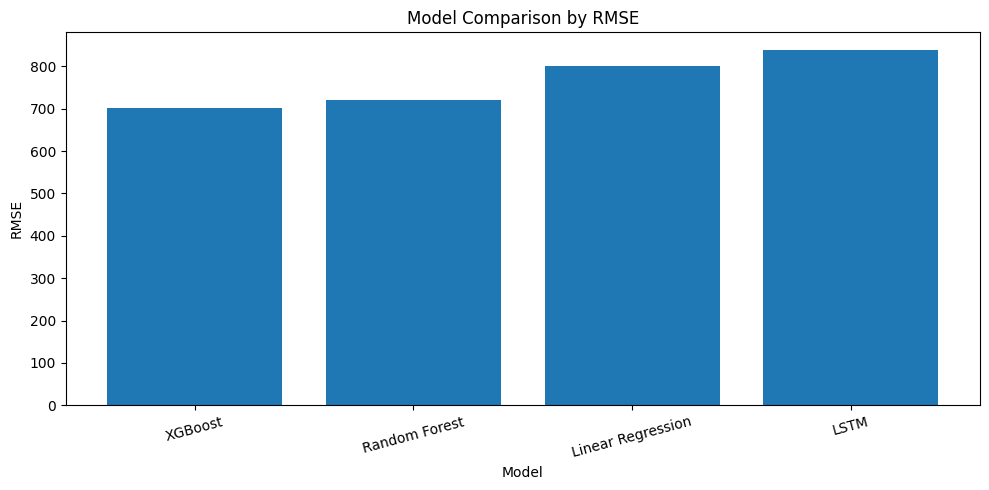

In [6]:
# Plot RMSE Comparison
plt.figure(figsize=(10, 5))
plt.bar(model_comparison["model"], model_comparison["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

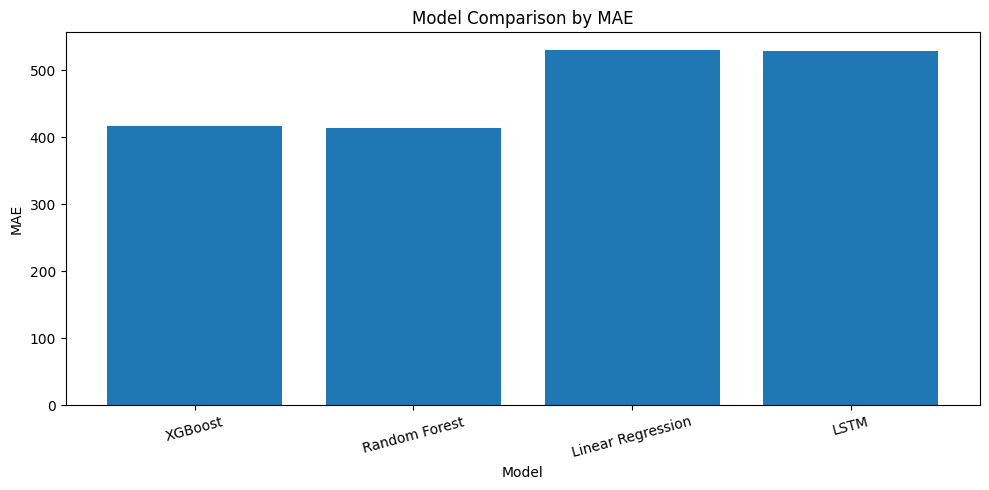

In [7]:
# Plot MAE Comparison
plt.figure(figsize=(10, 5))
plt.bar(model_comparison["model"], model_comparison["MAE"])
plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

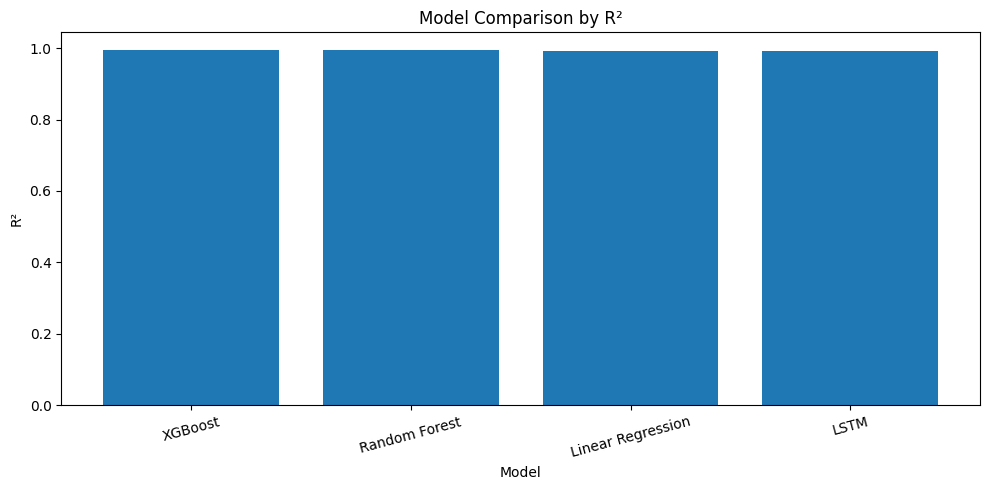

In [8]:
# Plot R² comparison
plt.figure(figsize=(10, 5))
plt.bar(model_comparison["model"], model_comparison["R2"])
plt.title("Model Comparison by R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [9]:
print(
    f"The best model is {best_model['model']} "
    f"with RMSE = {best_model['RMSE']:.2f}, "
    f"MAE = {best_model['MAE']:.2f}, "
    f"and R² = {best_model['R2']:.4f}."
)

The best model is XGBoost with RMSE = 701.70, MAE = 416.17, and R² = 0.9945.


## Model Comparison Summary

The models were compared using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The best-performing model is selected primarily based on the lowest RMSE, supported by MAE and R².

This comparison helps identify the most effective forecasting approach for NHS A&E demand prediction.